In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 69 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    521 non-null    float64
 1   ztfname                           521 non-null    object 
 2   ZTF_redshift                      521 non-null    float64
 3   ZTF_redshift_err                  521 non-null    float64
 4   ZTF_source                        521 non-null    object 
 5   ZTF_t0                            521 non-null    float64
 6   ZTF_x0                            521 non-null    float64
 7   ZTF_x1                            521 non-null    float64
 8   ZTF_c                             521 non-null    float64
 9   ZTF_t0_err                        521 non-null    float64
 10  ZTF_x0_err                        521 non-null    float64
 11  ZTF_x1_err                        521 non-null    float64
 12  ZTF_c_er

In [3]:
feature_cols = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z"
]

target_col = "residuals"

yerr_all = df["ZTF_sigma_mu"]

X = df[feature_cols]
y = df[target_col]

In [4]:
Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=42
)

# Optional: convert training pieces to numpy for easier CV indexing
Xtr_np = Xtr.to_numpy()
ytr_np = ytr.to_numpy()
yerr_tr_np = yerr_tr.to_numpy()

In [5]:
def weighted_rmse(y_true, y_pred, yerr):
    w = 1.0 / (yerr ** 2)
    return np.sqrt(np.sum(w * (y_true - y_pred) ** 2) / np.sum(w))

In [6]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "n_jobs": -1,
        "random_state": 42,
    }

    if params["bootstrap"]:
        params["max_samples"] = trial.suggest_float("max_samples", 0.5, 1.0)

    rf = RandomForestRegressor(**params)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    for train_idx, val_idx in kf.split(Xtr_np):
        X_fold_tr = Xtr_np[train_idx]
        X_fold_val = Xtr_np[val_idx]

        y_fold_tr = ytr_np[train_idx]
        y_fold_val = ytr_np[val_idx]

        yerr_fold_tr = yerr_tr_np[train_idx]
        yerr_fold_val = yerr_tr_np[val_idx]

        w_fold_tr = 1.0 / (yerr_fold_tr ** 2)

        rf.fit(X_fold_tr, y_fold_tr, sample_weight=w_fold_tr)
        y_fold_pred = rf.predict(X_fold_val)

        score = weighted_rmse(y_fold_val, y_fold_pred, yerr_fold_val)
        fold_scores.append(score)

    return np.mean(fold_scores)

In [7]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best trial:", study.best_trial.number)
print("Best weighted CV RMSE:", study.best_value)
print("Best hyperparameters:")
print(study.best_params)

[I 2026-04-07 15:24:20,431] A new study created in memory with name: no-name-52240cf2-72c0-45a6-9260-83a7d965aa86


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-07 15:24:23,001] Trial 0 finished with value: 0.16534633847060978 and parameters: {'n_estimators': 1400, 'max_depth': 3, 'min_samples_split': 19, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.952318078154408}. Best is trial 0 with value: 0.16534633847060978.
[I 2026-04-07 15:24:23,755] Trial 1 finished with value: 0.1687160851568496 and parameters: {'n_estimators': 400, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True, 'max_samples': 0.7075184742965872}. Best is trial 0 with value: 0.16534633847060978.
[I 2026-04-07 15:24:24,355] Trial 2 finished with value: 0.16672025234241877 and parameters: {'n_estimators': 300, 'max_depth': 27, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True, 'max_samples': 0.9066168504161544}. Best is trial 0 with value: 0.16534633847060978.
[I 2026-04-07 15:24:26,581] Trial 3 finished with value: 0.16806440472781864 a

In [8]:
best_params = study.best_params.copy()
best_params["n_jobs"] = -1
best_params["random_state"] = 42

rf = RandomForestRegressor(**best_params)

w = 1.0 / (yerr_tr.to_numpy() ** 2)

rf.fit(Xtr, ytr, sample_weight=w)
yhat = rf.predict(Xte)

In [9]:
test_weighted_rmse = weighted_rmse(yte.to_numpy(), yhat, yerr_te.to_numpy())
test_rmse = np.sqrt(mean_squared_error(yte, yhat))

print("Test weighted RMSE:", test_weighted_rmse)
print("Test RMSE:", test_rmse)

Test weighted RMSE: 0.182542818327191
Test RMSE: 0.19509719919218615


In [10]:
print("Feature Importances:")
feature_importances = pd.Series(rf.feature_importances_, index=feature_cols)
print(feature_importances.sort_values(ascending=False))

Feature Importances:
DESI_FASTSPEC_g_minus_r    0.318255
DESI_FASTSPEC_DN4000       0.207598
DESI_METADATA_Z            0.149025
DESI_FASTSPEC_LOGMSTAR     0.148867
DESI_FASTSPEC_AGE          0.103329
DESI_FASTSPEC_VDISP        0.042736
DESI_FASTSPEC_SFR          0.030191
dtype: float64


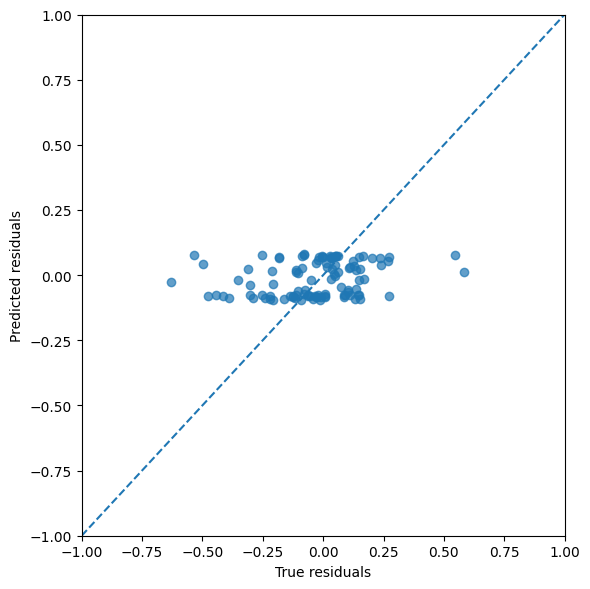

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(yte, yhat, alpha=0.7)
plt.xlabel("True residuals")
plt.ylabel("Predicted residuals")
plt.axline((0, 0), slope=1, linestyle="--")

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import binned_statistic

nbins = 10
point_kwargs = dict(alpha=0.2, s=50, color="grey", zorder=3)

def scatter_with_errors(ax, xcol, nbins=None, xerr_col=None, xerr_direct_col=None):
    """
    Plots scatter cloud with y-error bars, optional x-error bars, 
    and binned means with spread error bars.
    
    xerr_col      — column name of INVERSE VARIANCE (e.g. DESI_FASTSPEC_DN4000_IVAR)
    xerr_direct_col — column name of direct error (e.g. ZTF_x1_err)
    """
    x = df[xcol]
    y = df["residuals"]
    yerr = df["ZTF_sigma_mu"]

    # Optional horizontal error bars
    if xerr_col is not None:
        xerr = 1.0 / np.sqrt(df[xerr_col])
    elif xerr_direct_col is not None:
        xerr = df[xerr_direct_col]
    else:
        xerr = None

    # --- scatter cloud ---
    ax.scatter(x, y, **point_kwargs)

    # --- individual error bars ---
    ax.errorbar(
        x, y, yerr=yerr, xerr=xerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.5,
        alpha=0.25,
        zorder=2,
    )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange")

    # --- BINNING WITH ERROR PROPAGATION ---
    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    binned_y = []
    binned_yerr = []

    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        if np.sum(in_bin) == 0:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue

        y_bin = y[in_bin]
        y_mean = np.mean(y_bin)
        err_spread = np.std(y_bin, ddof=1)

        binned_y.append(y_mean)
        binned_yerr.append(err_spread)

    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color="blue",
        markersize=7,
        capsize=3,
        zorder=5,
    )

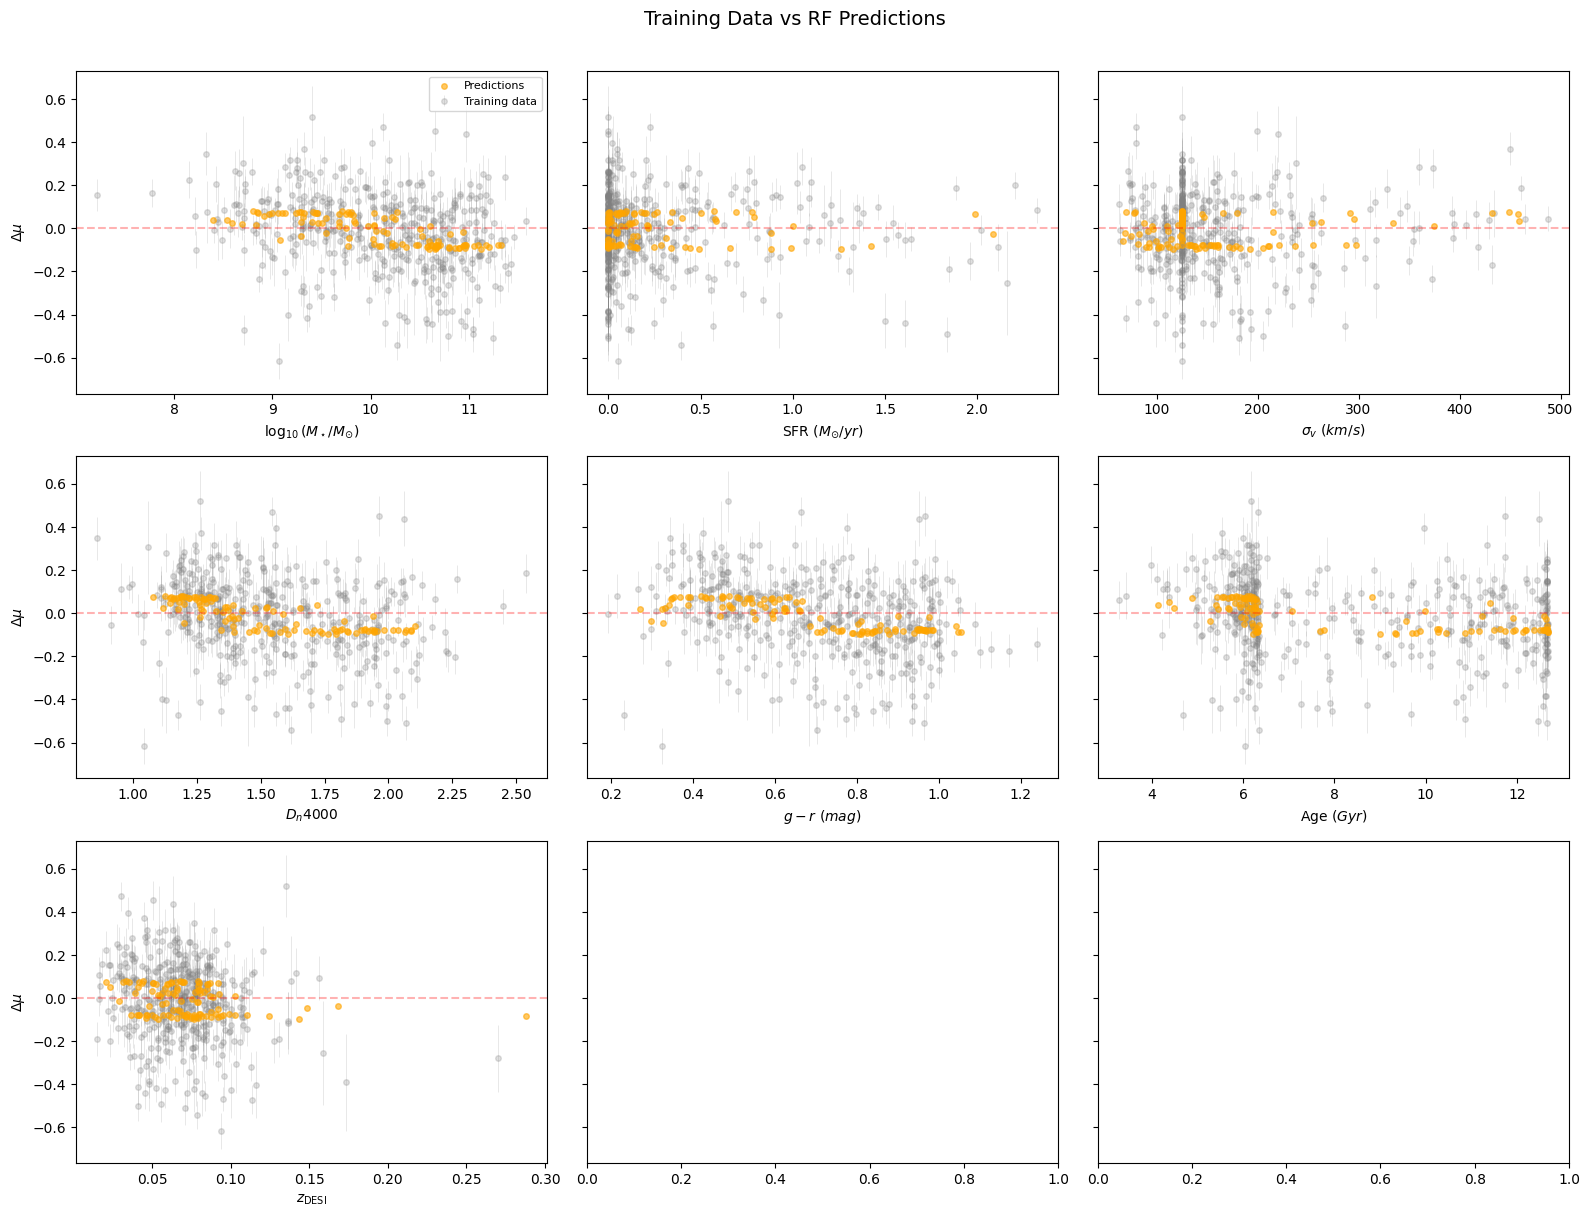

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharey=True)
axes = axes.flatten()

plot_features = feature_cols
plot_labels = [
    r"$\log_{10}(M_\star / M_{\odot})$",
    r"${\rm SFR}\ (M_{\odot}/yr)$",
    r"$\sigma_v\ (km/s)$",
    r"$D_n4000$",
    r"$g - r\ (mag)$",
    r"${\rm Age}\ (Gyr)$",
    r"$z_{\rm DESI}$",
    r"$x_1$",
    r"$c$",
]

for i, (feat, label) in enumerate(zip(plot_features, plot_labels)):
    ax = axes[i]
    ax.errorbar(
        Xtr[feat], ytr,
        yerr=yerr_tr,
        fmt="o", markersize=4, alpha=0.25,
        color="gray", ecolor="gray", elinewidth=0.5, capsize=0,
        label="Training data", zorder=1,
    )
    ax.scatter(
        Xte[feat], yhat,
        alpha=0.6, s=16, color="orange",
        label="Predictions", zorder=2,
    )
    ax.set_xlabel(label)
    if i % 3 == 0:
        ax.set_ylabel(r"$\Delta \mu$")
    ax.axhline(0, linestyle="--", color="red", alpha=0.3)

axes[0].legend(fontsize=8)
fig.suptitle("Training Data vs RF Predictions", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

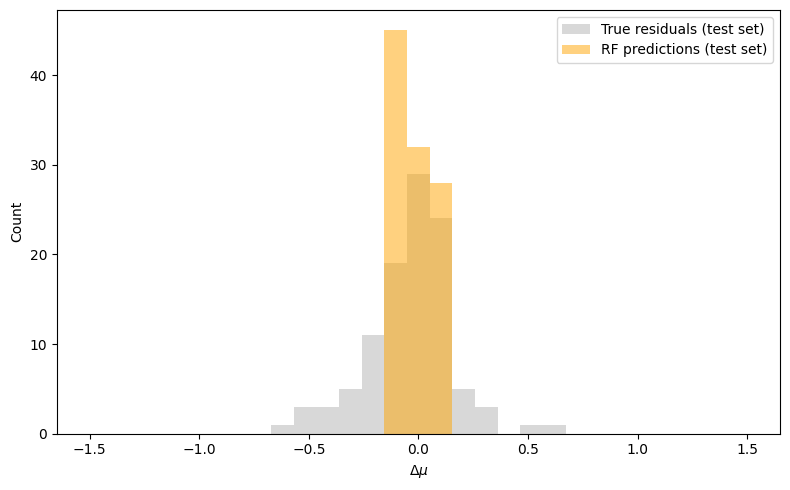

In [14]:
bins = np.linspace(-1.5, 1.5, 30)

plt.figure(figsize=(8, 5))
plt.hist(yte, bins=bins, alpha=0.3, color="grey", label="True residuals (test set)")
plt.hist(yhat, bins=bins, alpha=0.5, color="orange", label="RF predictions (test set)")
plt.xlabel(r"$\Delta \mu$")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

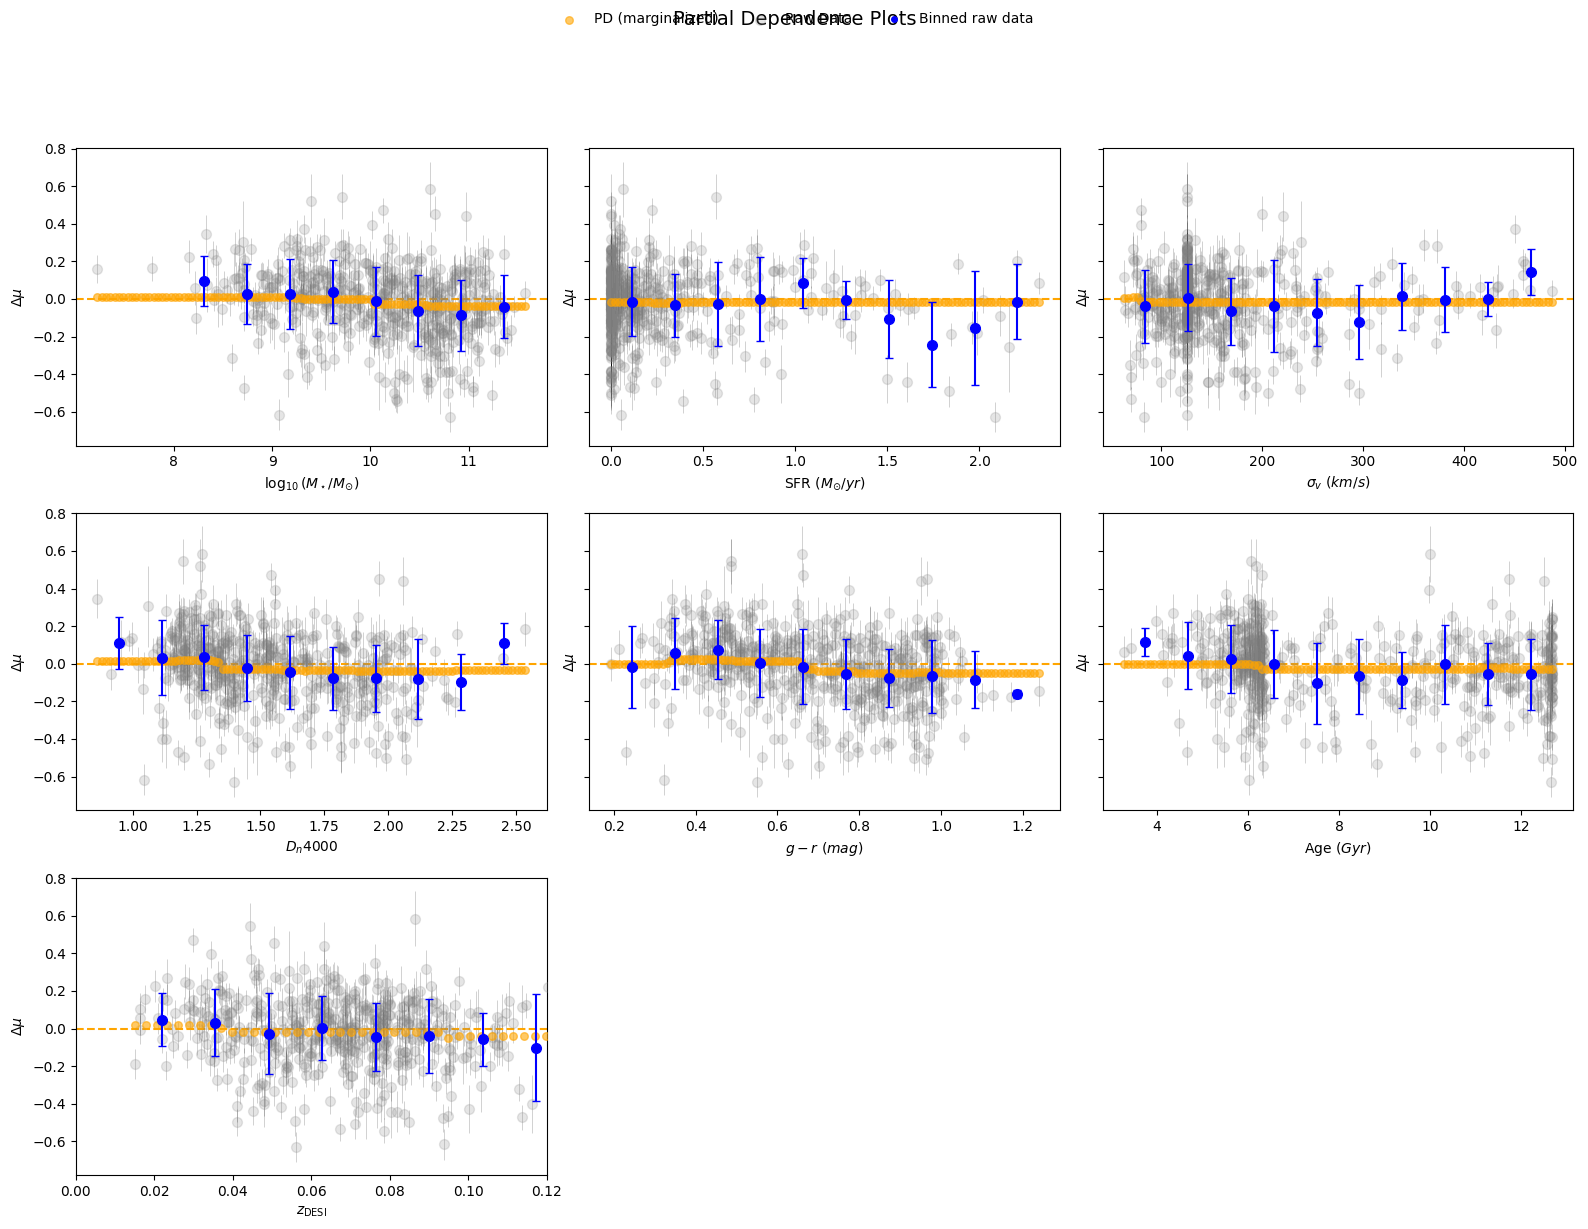

In [16]:
from sklearn.inspection import partial_dependence

# Map column names to pretty LaTeX labels
FEATURE_LABELS = {
    "DESI_FASTSPEC_LOGMSTAR":    r"$\log_{10}(M_\star / M_{\odot})$",
    "DESI_FASTSPEC_SFR":         r"${\rm SFR}\ (M_{\odot}/yr)$",
    "DESI_FASTSPEC_VDISP":       r"$\sigma_v\ (km/s)$",
    "DESI_FASTSPEC_DN4000":      r"$D_n4000$",
    "DESI_FASTSPEC_g_minus_r":   r"$g - r\ (mag)$",
    "DESI_FASTSPEC_AGE":         r"${\rm Age}\ (Gyr)$",
    "DESI_METADATA_Z":           r"$z_{\rm DESI}$",
    "ZTF_x1":                    r"$x_1$",
    "ZTF_c":                     r"$c$",
}

def plot_pd_panel(ax, feature, rf, X, feature_cols, nbins=10, method="recursion"):
    X_pd = X[feature_cols]

    res = partial_dependence(
        estimator=rf,
        X=X_pd,
        features=[feature],
        method=method,
        percentiles=(0.00, 1.00),
    )
    x_grid = res["grid_values"][0]
    y_grid = res["average"][0]

    # PD curve
    ax.scatter(x_grid, y_grid, alpha=0.6, s=30, color="orange",
               label="PD (marginalized)", zorder=4)

    # Raw + binned overlay
    global point_kwargs
    old_kwargs = point_kwargs.copy()
    point_kwargs.update({"label": "Raw Data"})
    scatter_with_errors(ax, feature, nbins=nbins)
    point_kwargs.clear()
    point_kwargs.update(old_kwargs)

    ax.errorbar([], [], fmt="o", color="blue", markersize=4, label="Binned raw data")

    # Axis labels
    ax.set_xlabel(FEATURE_LABELS.get(feature, feature))
    ax.set_ylabel(r"$\Delta \mu$")


fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharey=True)

plot_pd_panel(axes[0, 0], "DESI_FASTSPEC_LOGMSTAR",    rf, X, feature_cols, nbins=nbins)
plot_pd_panel(axes[0, 1], "DESI_FASTSPEC_SFR",          rf, X, feature_cols, nbins=nbins)
plot_pd_panel(axes[0, 2], "DESI_FASTSPEC_VDISP",        rf, X, feature_cols, nbins=nbins)

plot_pd_panel(axes[1, 0], "DESI_FASTSPEC_DN4000",       rf, X, feature_cols, nbins=nbins)
plot_pd_panel(axes[1, 1], "DESI_FASTSPEC_g_minus_r",    rf, X, feature_cols, nbins=nbins)
plot_pd_panel(axes[1, 2], "DESI_FASTSPEC_AGE",          rf, X, feature_cols, nbins=nbins)

plot_pd_panel(axes[2, 0], "DESI_METADATA_Z",            rf, X, feature_cols, nbins=20)
axes[2, 0].set_xlim(0, 0.12)
axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

fig.suptitle("Partial Dependence Plots", fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()